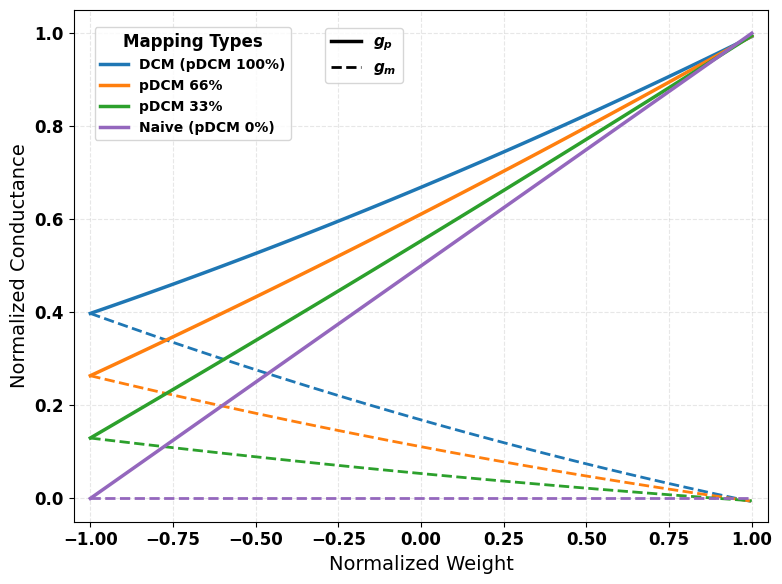

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
g_min = 0.1
g_max = 25.0
g_range = g_max - g_min

# Weight 범위를 [-1, 1]로 설정 (100 points)
w_norm = np.linspace(0.0, 1.0, 100) # 기존 수식 계산용 (0 to 1)
w_plot = np.linspace(-1.0, 1.0, 100) # 실제 x축 출력용 (-1 to 1)

# --- 1) Optimal mapping (DCM 100%) ---
gp_opt = 2.64268112*w_norm**2 + 12.1806845*w_norm + 10.00479516
gm_opt = 2.64268112*w_norm**2 - 12.7193155*w_norm + 10.00479516

# Distortion base (GM polynomial)
gm_poly = 2.64268112*w_norm**2 - 12.7193155*w_norm + 10.00479516

# --- 2) 33% distortion ---
gm_33 = (1.0 - 1.0/3.0) * gm_poly
gp_33 = w_norm * g_range + gm_33

# --- 3) 66% distortion ---
gm_66 = (1.0 - 2.0/3.0) * gm_poly
gp_66 = w_norm * g_range + gm_66

# --- 4) Naive mapping ---
gp_naive = g_min + w_norm * g_range
gm_naive = g_min * np.ones_like(w_norm)

# --- Normalize conductances to [0, 1] ---
def g_norm(g):
    return (g - g_min) / g_range

# 데이터 정리
data = {
    'DCM (pDCM 100%)': (g_norm(gp_opt), g_norm(gm_opt)),
    'pDCM 66%':        (g_norm(gp_33), g_norm(gm_33)),
    'pDCM 33%':        (g_norm(gp_66), g_norm(gm_66)),
    'Naive (pDCM 0%)': (g_norm(gp_naive), g_norm(gm_naive))
}

# --- Plotting ---
plt.rcParams.update({'font.size': 12, 'font.weight': 'bold'})
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd'] # C0, C1, C2, C3 스타일
lines_list = []

for i, (label, (gp, gm)) in enumerate(data.items()):
    l1, = ax.plot(w_plot, gp, color=colors[i], linewidth=2.5, linestyle='-', label=label)
    l2, = ax.plot(w_plot, gm, color=colors[i], linewidth=2.0, linestyle='--')
    lines_list.append(l1)

# Style Legend 요소를 위한 가상 라인
from matplotlib.lines import Line2D
style_elements = [Line2D([0], [0], color='black', lw=2.5, linestyle='-', label='$g_p$'),
                  Line2D([0], [0], color='black', lw=2.0, linestyle='--', label='$g_m$')]

# 첫 번째 범례 (Mapping 방식)
leg1 = ax.legend(handles=lines_list, loc='upper left', bbox_to_anchor=(0.02, 0.98),
                 frameon=True, fontsize=10, title="Mapping Types")
ax.add_artist(leg1)

# 두 번째 범례 (gp vs gm 스타일)
leg2 = ax.legend(handles=style_elements, loc='upper left', bbox_to_anchor=(0.35, 0.98),
                 frameon=True, fontsize=11)

# 그래프 디테일 설정
ax.set_xlabel('Normalized Weight', fontsize=14)
ax.set_ylabel('Normalized Conductance', fontsize=14)
ax.set_xlim([-1.05, 1.05])
ax.set_ylim([-0.05, 1.05])
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
# plt.savefig('various_mapping_python.png', dpi=300)
plt.show()

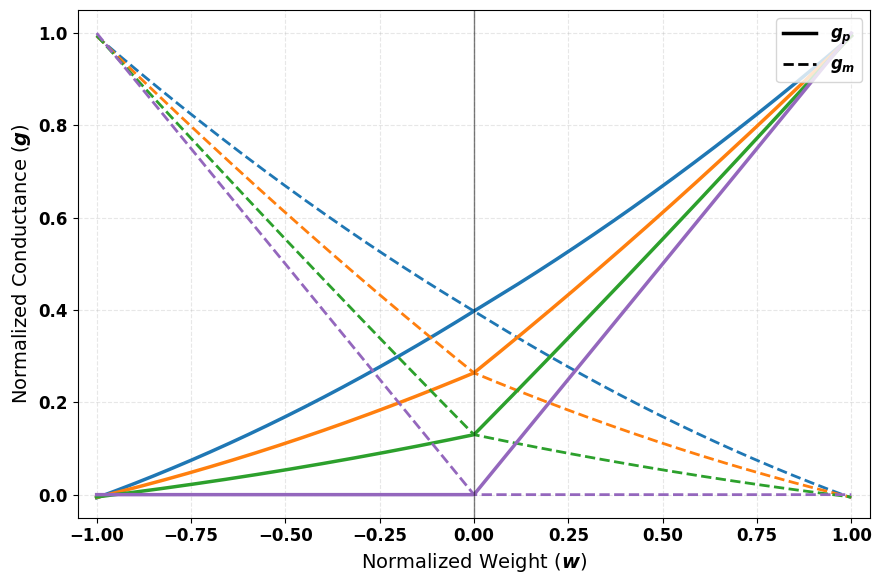

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Parameters ---
g_min = 0.1
g_max = 25.0
g_range = g_max - g_min

# Weight 범위를 [-1, 1]로 설정
w_plot = np.linspace(-1.0, 1.0, 400)

def get_conductances(w_val):
    # w_val의 절대값을 사용하여 기본 polynomial 계산
    w_abs = np.abs(w_val)
    
    # 1) Optimal base
    gp_opt_base = 2.64268112*w_abs**2 + 12.1806845*w_abs + 10.00479516
    gm_opt_base = 2.64268112*w_abs**2 - 12.7193155*w_abs + 10.00479516
    
    # 2) Distortion bases (GM poly 기반)
    gm_poly = 2.64268112*w_abs**2 - 12.7193155*w_abs + 10.00479516
    
    # 각 타입별 계산 (Positive w 기준)
    # Optimal
    gp_o, gm_o = gp_opt_base, gm_opt_base
    # 33%
    gm_33_b = (1.0 - 1.0/3.0) * gm_poly
    gp_33_b = w_abs * g_range + gm_33_b
    # 66%
    gm_66_b = (1.0 - 2.0/3.0) * gm_poly
    gp_66_b = w_abs * g_range + gm_66_b
    # Naive
    gp_n_b = g_min + w_abs * g_range
    gm_n_b = g_min * np.ones_like(w_abs)

    results = []
    for gp_b, gm_b in [(gp_o, gm_o), (gp_33_b, gm_33_b), (gp_66_b, gm_66_b), (gp_n_b, gm_n_b)]:
        # w < 0 일 때 gp = gm_base, gm = gp_base (역할 교체 및 대칭)
        gp = np.where(w_val >= 0, gp_b, gm_b)
        gm = np.where(w_val >= 0, gm_b, gp_b)
        results.append((gp, gm))
    
    return results

# 컨덕턴스 계산 및 정규화
raw_results = get_conductances(w_plot)
g_norm = lambda g: (g - g_min) / g_range

data = {
    'DCM (pDCM 100%)': (g_norm(raw_results[0][0]), g_norm(raw_results[0][1])),
    'pDCM 66%':        (g_norm(raw_results[1][0]), g_norm(raw_results[1][1])),
    'pDCM 33%':        (g_norm(raw_results[2][0]), g_norm(raw_results[2][1])),
    'Naive (pDCM 0%)': (g_norm(raw_results[3][0]), g_norm(raw_results[3][1]))
}

# --- Plotting ---
plt.rcParams.update({'font.size': 12, 'font.weight': 'bold'})
fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']
lines_list = []

for i, (label, (gp, gm)) in enumerate(data.items()):
    l1, = ax.plot(w_plot, gp, color=colors[i], linewidth=2.5, linestyle='-', label=label)
    l2, = ax.plot(w_plot, gm, color=colors[i], linewidth=2.0, linestyle='--')
    lines_list.append(l1)

# 범례 설정
style_elements = [Line2D([0], [0], color='black', lw=2.5, linestyle='-', label='$g_p$'),
                  Line2D([0], [0], color='black', lw=2.0, linestyle='--', label='$g_m$')]

leg1 = ax.legend(handles=lines_list, loc='upper center', bbox_to_anchor=(0.5, -0.15),
                 ncol=2, frameon=True, title="Mapping Types")
ax.add_artist(leg1)

leg2 = ax.legend(handles=style_elements, loc='upper right', frameon=True)

# 그래프 디테일
ax.set_xlabel('Normalized Weight ($w$)', fontsize=14)
ax.set_ylabel('Normalized Conductance ($g$)', fontsize=14)
ax.set_xlim([-1.05, 1.05])
ax.set_ylim([-0.05, 1.05])
ax.grid(True, alpha=0.3, linestyle='--')
ax.axvline(0, color='black', linewidth=1, alpha=0.5) # y축 중심선

plt.tight_layout()
plt.show()

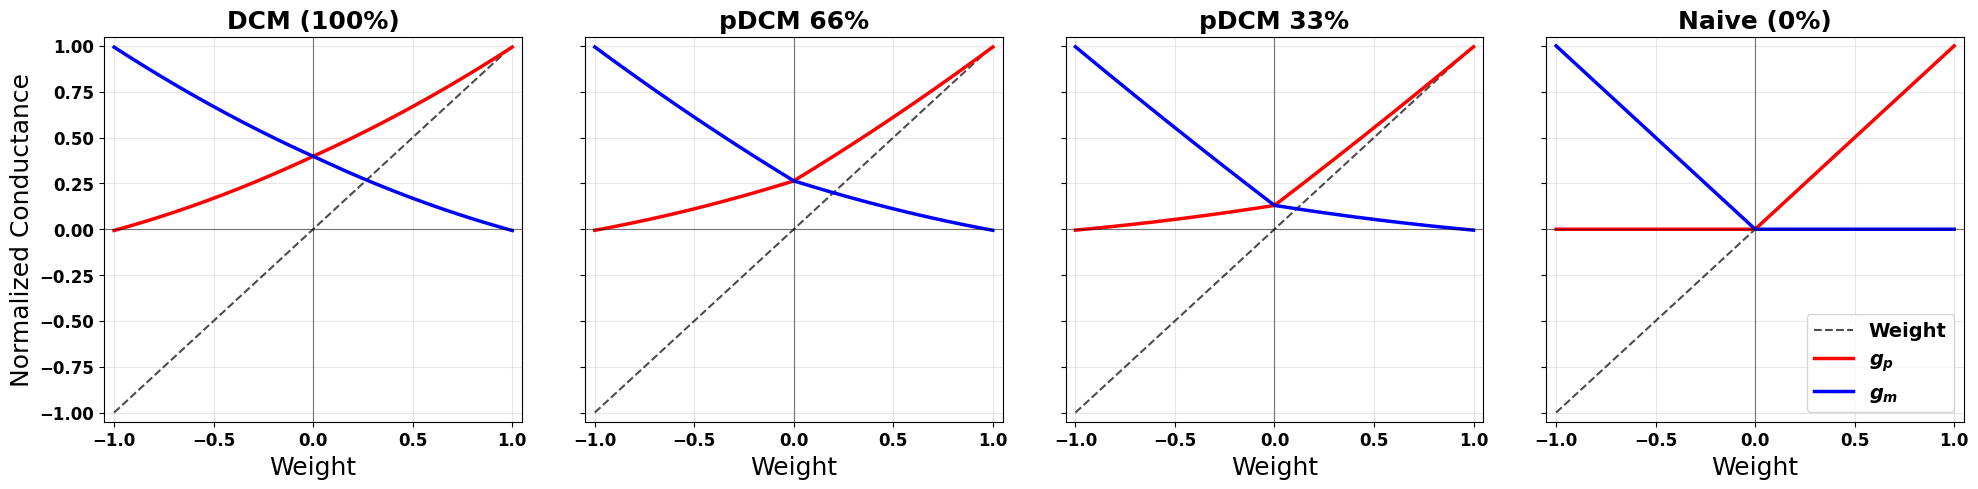

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Parameters ---
g_min = 0.1
g_max = 25.0
g_range = g_max - g_min

# Weight 범위를 [-1, 1]로 설정
w_plot = np.linspace(-1.0, 1.0, 400)

def get_mapping_data(w_val):
    w_abs = np.abs(w_val)
    
    # Base polynomials (for w > 0)
    gp_opt_b = 2.64268112*w_abs**2 + 12.1806845*w_abs + 10.00479516
    gm_opt_b = 2.64268112*w_abs**2 - 12.7193155*w_abs + 10.00479516
    gm_poly = gm_opt_b # Distortion base
    
    # 1. Optimal (100%)
    # 2. 66% distortion
    gm_66_b = (1.0 - 1.0/3.0) * gm_poly
    gp_66_b = w_abs * g_range + gm_66_b
    # 3. 33% distortion
    gm_33_b = (1.0 - 2.0/3.0) * gm_poly
    gp_33_b = w_abs * g_range + gm_33_b
    # 4. Naive (0%)
    gp_n_b = g_min + w_abs * g_range
    gm_n_b = g_min * np.ones_like(w_abs)

    bases = [(gp_opt_b, gm_opt_b), (gp_66_b, gm_66_b), (gp_33_b, gm_33_b), (gp_n_b, gm_n_b)]
    
    final_data = []
    for gp_b, gm_b in bases:
        # Symmetry: w < 0 이면 gp = gm_base, gm = gp_base
        gp = np.where(w_val >= 0, gp_b, gm_b)
        gm = np.where(w_val >= 0, gm_b, gp_b)
        # Normalize to [0, 1]
        final_data.append(((gp - g_min)/g_range, (gm - g_min)/g_range))
        
    return final_data

data_list = get_mapping_data(w_plot)
titles = ['DCM (100%)', 'pDCM 66%', 'pDCM 33%', 'Naive (0%)']

# --- Plotting (1x4 Structure) ---
fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharey=True)
plt.rcParams.update({'font.weight': 'bold'})

for i, ax in enumerate(axes):
    gp_norm, gm_norm = data_list[i]
    
    # y = x 참조선 (Black dashed)
    ax.plot([-1, 1], [-1, 1], color='black', linestyle='--', linewidth=1.5, label='Weight', alpha=0.7)
    
    # gp (Red), gm (Blue)
    ax.plot(w_plot, gp_norm, color='red', linewidth=2.5, label='$g_p$')
    ax.plot(w_plot, gm_norm, color='blue', linewidth=2.5, label='$g_m$')
    
    # 차트 설정
    ax.set_title(titles[i], fontsize=18, fontweight='bold')
    ax.set_xlabel('Weight', fontsize=18)
    if i == 0:
        ax.set_ylabel('Normalized Conductance', fontsize=18)
    
    ax.set_xlim([-1.05, 1.05])
    ax.set_ylim([-1.05, 1.05]) # y=x 선을 위해 범위를 -1까지 확장
    ax.grid(True, alpha=0.3)
    ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    
    if i == 3: # 마지막 플롯에만 범례 표시
        ax.legend(loc='lower right', fontsize=14)

plt.subplots_adjust(wspace=0.15)
# plt.tight_layout()
plt.show()